# Task 4.4 — Geo Mean HAI Across Vaccine Strains (D28)

**4.4 Predict magnitude of antibody response - all 3 vaccine strains (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Geo mean / Metric: Spearman correlation
* Full description: Geo mean of HAI across the 3 vaccine strains at Day 28

> **Note — missing strain:** `H3N2 A/Massachusetts/18/2022` has no direct D28 measurements in the training data. A proxy is constructed from the row-wise mean of all H3N2 D28 HAI columns (same approach as Task 4.2), which is highly correlated with the missing strain's response. The target is the mean of all 3 vaccine strain components: H1N1 direct + H3N2 proxy + Vic B direct.

---

**Target:** arithmetic mean of log2 HAI at D28 across 3 vaccine strain components = log2(geometric mean) on the raw titer scale. `np.exp2` is applied to predictions before saving.

**Features:** demographics + D0 HAI + D7 innate (after sparse/constant/leakage filtering). All D28 and D365 columns excluded to prevent leakage.

**CV:** best base model (non-StackedEnsemble), 5-fold; Spearman correlation on holdout predictions.

In [1]:
VACCINE_STRAINS = [
    'H1N1 A/Victoria/4897/2022',
    'H3N2 A/Massachusetts/18/2022',
    'Vic B/Austria/1359417/2021',
]
TARGET_COL = 'TARGET_4_4'
AUTO_ML_MAX_RUNTIME_SECONDS = 600

In [2]:
PARQUET_PATH = '../merged_data/combined.parquet'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = '../automl_submission'

In [3]:
import pyarrow
import io
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [4]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 23)


### Preprocessing — target construction

The task target is the **arithmetic mean of log2 HAI** across all 3 vaccine strain components at D28, which equals log2(geometric mean) on the raw titer scale.

`H3N2 A/Massachusetts/18/2022` has no D28 column in the training data. Following Task 4.2's approach, we build a proxy (`H3N2_proxy_d28`) as the row-wise mean of **all** H3N2 D28 HAI columns — H3N2 strains within a season are highly correlated in titer response.

The target is then the mean of 3 components:
- `HAI_H1N1 A/Victoria/4897/2022_d28` (direct)
- `H3N2_proxy_d28` (proxy for missing vaccine strain)
- `HAI_Vic B/Austria/1359417/2021_d28` (direct)

All D28 columns (including `H3N2_proxy_d28`, which ends with `_d28`) are dropped in the leakage-prevention step.

In [5]:
df = pd.read_parquet(PARQUET_PATH)
print(f'Pre-filtered shape: {df.shape}')

Pre-filtered shape: (3757, 110063)


In [6]:
# Build H3N2 proxy (row-wise mean of all H3N2 d28 cols) as stand-in for missing vaccine strain
h3n2_d28_cols = [c for c in df.columns if c.startswith('HAI_') and 'H3N2' in c and c.endswith('_d28')]
print(f'Found {len(h3n2_d28_cols)} H3N2 d28 columns for proxy.')
df['H3N2_proxy_d28'] = df[h3n2_d28_cols].mean(axis=1, skipna=True)

# Direct vaccine strain d28 columns (H1N1 and Vic B have actual measurements; H3N2 uses the proxy)
direct_vaccine_d28_cols = [
    c for c in df.columns
    if c.startswith('HAI_') and c.endswith('_d28')
    and any(s in c for s in VACCINE_STRAINS) and 'H3N2' not in c
]
print(f'Direct vaccine d28 columns: {direct_vaccine_d28_cols}')

# Target = mean of 3 components: H1N1 direct + H3N2 proxy + Vic B direct
target_components = direct_vaccine_d28_cols + ['H3N2_proxy_d28']
df[TARGET_COL] = df[target_components].mean(axis=1, skipna=True)
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Filtered shape: {df.shape}')

Found 25 H3N2 d28 columns for proxy.
Direct vaccine d28 columns: ['HAI_H1N1 A/Victoria/4897/2022_d28', 'HAI_Vic B/Austria/1359417/2021_d28']
Filtered shape: (3568, 110065)


In [7]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns. New shape: {df.shape}')

Dropped 26510 all-null columns. New shape: (3568, 83555)


### Coerce HAI string columns to numeric

Some `HAI_*` titer columns are stored as strings (e.g. censored values like `<10` or stringified NaN). H2O treats those as categorical at training time but numeric at prediction time, which crashes `predict()`. We coerce all `HAI_*` string columns to numeric (non-numeric values become NaN). Genuine categoricals (demographics) are left alone.

In [8]:
str_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f'String columns ({len(str_cols)}):', str_cols)

String columns (5): ['participant_id', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']


In [9]:
for c in str_cols:
    print(f'  {c}: sample={df[c].dropna().unique()[:5].tolist()}')

hai_str_cols = [c for c in str_cols if c.startswith('HAI_')]
for c in hai_str_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
print(f'\nCoerced {len(hai_str_cols)} HAI string columns to numeric.')
print(f'Remaining string columns: {df.select_dtypes(include=["object", "str"]).columns.tolist()}')

challenge_hai_str_cols = [
    c for c in challenge_data.select_dtypes(include=['object', 'str']).columns
    if c.startswith('HAI_')
]
for c in challenge_hai_str_cols:
    challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Coerced {len(challenge_hai_str_cols)} HAI string columns in challenge data.')

  participant_id: sample=['SDY269.SUB112836', 'SDY269.SUB112849', 'SDY269.SUB112854', 'SDY269.SUB112860', 'SDY269.SUB112881']
  PART_biological_sex: sample=['Female', 'Male']
  PART_race: sample=['White', 'Black', 'Asian', 'American Indian', 'Other']
  PART_geolocation: sample=['Georgia', 'Connecticut', 'Texas', 'California', 'Minnesota']
  PART_arm_name: sample=['Other', 'Standard Fluzone', 'High Dose Fluzone']

Coerced 0 HAI string columns to numeric.
Remaining string columns: ['participant_id', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']
Coerced 0 HAI string columns in challenge data.


### Drop constant features

Any column with only one unique value (numeric or categorical) carries no signal. Since we filtered to participants with this specific target, some categorical features that vary across the full dataset (e.g. `PART_race`, `PART_geolocation`) may collapse to a single value here.

In [10]:
constant_cols = [
    c for c in df.columns
    if c != TARGET_COL and df[c].nunique(dropna=True) <= 1
]
df = df.drop(columns=constant_cols)
print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Shape: {df.shape}')

Dropped 63 constant columns: ['FLOW_Classical monocytes_d0', 'FLOW_Conventional DC_d0', 'FLOW_Neutrophils + Basophils_d0', 'FLOW_Classical monocytes_d7', 'FLOW_Conventional DC_d7', 'FLOW_Neutrophils + Basophils_d7', 'TRAN_ENSG00000204695_d7', 'TRAN_ENSG00000225012_d7', 'TRAN_ENSG00000225203_d7', 'TRAN_ENSG00000232309_d7', 'TRAN_ENSG00000249491_d7', 'TRAN_ENSG00000254787_d7', 'TRAN_ENSG00000286232_d0', 'TRAN_ENSG00000286391_d0', 'TRAN_ENSG00000288723_d0', 'TRAN_ENSG00000290669_d0', 'TRAN_ENSG00000290855_d0', 'TRAN_ENSG00000290909_d0', 'TRAN_ENSG00000293350_d0', 'TRAN_ENSG00000293876_d0', 'TRAN_ENSG00000294500_d0', 'TRAN_ENSG00000295176_d0', 'TRAN_ENSG00000295371_d0', 'TRAN_ENSG00000296345_d0', 'TRAN_ENSG00000298439_d0', 'TRAN_ENSG00000299622_d0', 'TRAN_ENSG00000300583_d0', 'TRAN_ENSG00000301618_d0', 'TRAN_ENSG00000302139_d0', 'TRAN_ENSG00000302927_d0', 'TRAN_ENSG00000305446_d0', 'TRAN_ENSG00000306888_d0', 'TRAN_ENSG00000307065_d0', 'TRAN_ENSG00000307366_d0', 'TRAN_ENSG00000307986_d0', '

### Drop sparse features

Drop columns missing in more than half the rows — they are too gappy for models to learn from and massively slow training (the full parquet has ~100k columns; after this step we expect ~50 or fewer).

In [11]:
MISSING_THRESHOLD = 0.5

miss_frac = df.isna().mean()
high_miss = [c for c in miss_frac[miss_frac > MISSING_THRESHOLD].index if c != TARGET_COL]
df = df.drop(columns=high_miss)
print(f'Dropped {len(high_miss)} columns with >{MISSING_THRESHOLD:.0%} missing.')
print(f'Shape: {df.shape}')

Dropped 83478 columns with >50% missing.
Shape: (3568, 14)


### Drop other-task target columns

The challenge participants only have baseline data (demographics + d0 + d7) — d28 and d365 measurements don't exist for them yet (those are what we're being asked to predict). If we leave other `_d28` / `_d365` columns in the feature set, the model will learn to lean on them during training, but at predict time they'll all be NaN for the challenge data. Drop them all.

In [12]:
other_target_cols = [
    c for c in df.columns
    if c.endswith('_d28') or c.endswith('_d365')
]
df = df.drop(columns=other_target_cols)
print(f'Dropped {len(other_target_cols)} other-task target columns.')
print(f'Final shape: {df.shape}')

Dropped 4 other-task target columns.
Final shape: (3568, 10)


In [13]:
print(f'Final shape: {df.shape}')
print(f'Target ({TARGET_COL}) stats (log2):\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')

Final shape: (3568, 10)
Target (TARGET_4_4) stats (log2):
count    3568.000000
mean        5.739259
std         1.999058
min         0.000000
25%         4.321928
50%         5.679071
75%         7.071928
max        14.321928
Name: TARGET_4_4, dtype: float64

dtype counts:
str        5
float64    5
Name: count, dtype: int64


---
## AutoML Setup

In [14]:
warnings.filterwarnings("ignore", category=UserWarning, module="h2o")
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Temurin-25.0.2+10 (build 25.0.2+10-LTS, mixed mode, sharing)
  Starting server from C:\Users\User\anaconda3\envs\cmi-flu-prediction-challenge-capstone\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\User\AppData\Local\Temp\tmpq_c_lr3a
  JVM stdout: C:\Users\User\AppData\Local\Temp\tmpq_c_lr3a\h2o_User_started_from_python.out
  JVM stderr: C:\Users\User\AppData\Local\Temp\tmpq_c_lr3a\h2o_User_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,00 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 27 days
H2O_cluster_name:,H2O_from_python_User_iwdmy8
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.41 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [15]:
data = h2o.H2OFrame(df)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (3568, 10)


---
## AutoML Training

In [16]:
y = TARGET_COL
x = [c for c in data.columns if c not in (y, 'participant_id')]
print(f'Training samples: {data.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(max_models=10, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=data)
print('Training complete.')

Training samples: 3568  |  Features: 8
Training complete.


In [17]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
lb_df

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,StackedEnsemble_AllModels_1_AutoML_1_20260509_...,1.533037,2.350204,1.174059,0.252153,2.350204
1,StackedEnsemble_BestOfFamily_1_AutoML_1_202605...,1.536629,2.361227,1.179226,0.252605,2.361227
2,GBM_2_AutoML_1_20260509_154912,1.538340,2.366490,1.182579,0.252271,2.366490
3,GBM_5_AutoML_1_20260509_154912,1.543316,2.381824,1.179354,0.253428,2.381824
4,GBM_3_AutoML_1_20260509_154912,1.546020,2.390177,1.185290,0.253491,2.390177
5,GBM_4_AutoML_1_20260509_154912,1.548548,2.398002,1.189453,0.253633,2.398002
6,GBM_1_AutoML_1_20260509_154912,1.549142,2.399842,1.191383,0.254178,2.399842
7,GBM_grid_1_AutoML_1_20260509_154912_model_1,1.556958,2.424118,1.195519,0.255063,2.424118
8,DRF_1_AutoML_1_20260509_154912,1.578669,2.492195,1.215663,0.259114,2.492195
9,GLM_1_AutoML_1_20260509_154912,1.605024,2.576101,1.234394,0.263835,2.576101


In [18]:
best_base_model_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
top_model = h2o.get_model(best_base_model_id)

cv_preds = top_model.cross_validation_holdout_predictions().as_data_frame(use_multi_thread=True)['predict']
actuals = data[y].as_data_frame(use_multi_thread=True)[y]

rho, pval = spearmanr(actuals, cv_preds)
print(f'Task 4.4 — Spearman (Best Base Model 5-fold CV): {rho:.3f}  (p={pval:.4f})')

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Task 4.4 — Spearman (Best Base Model 5-fold CV): 0.602  (p=0.0000)


Leader model: GBM_2_AutoML_1_20260509_154912


,variable,relative_importance,scaled_importance,percentage
0,PART_geolocation,15440.989258,1.000000,0.433900
1,PART_age,7829.116699,0.507035,0.220003
2,HAI_H1N1 A/California/7/2009_d0,5569.740234,0.360711,0.156513
3,HAI_Yam B/Phuket/3073/2013_d0,2034.691528,0.131772,0.057176
4,PART_race,1716.555908,0.111169,0.048236
5,PART_arm_name,1278.634766,0.082808,0.035930
6,HAI_Vic B/Colorado/6/2017_d0,975.367920,0.063167,0.027408
7,PART_biological_sex,741.383789,0.048014,0.020833


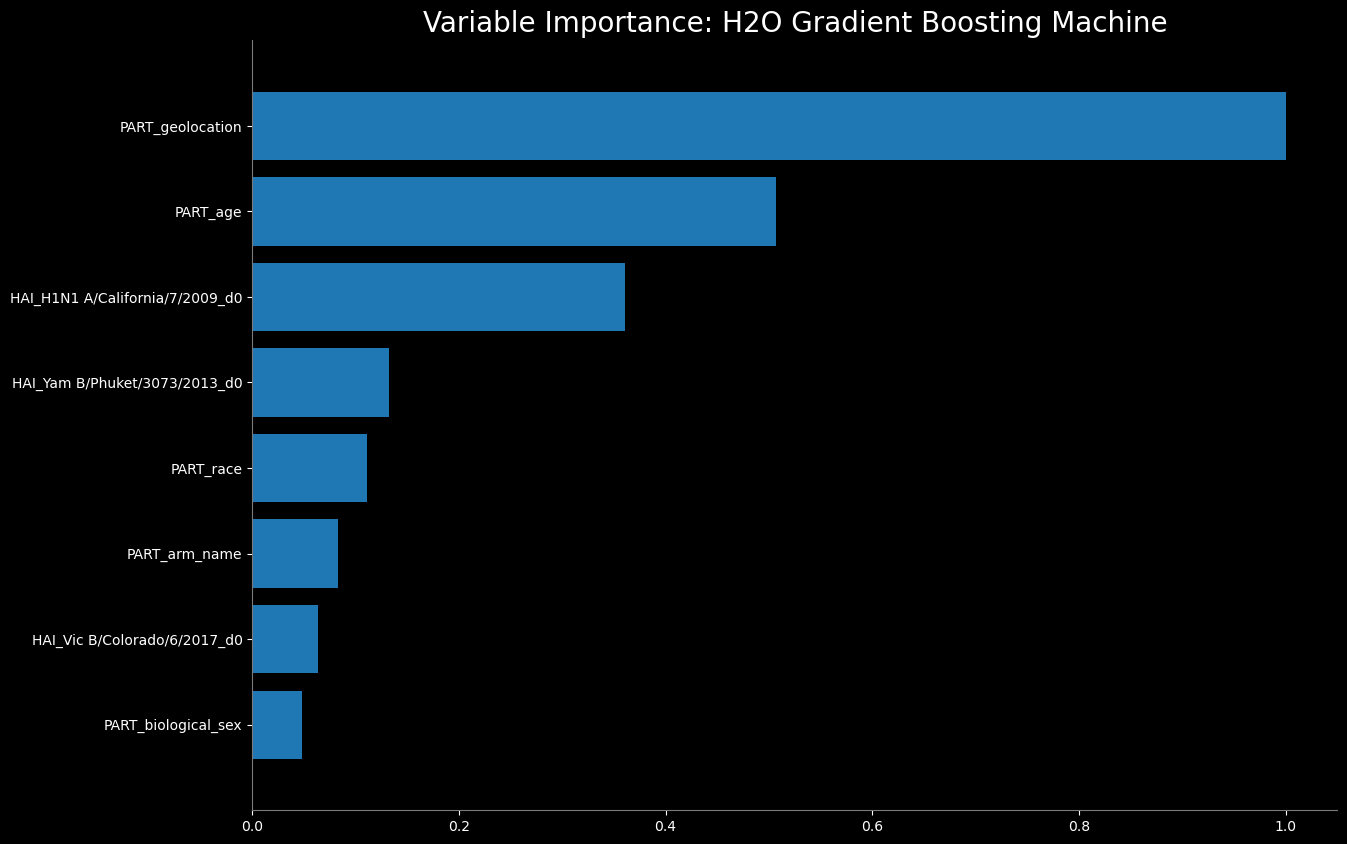

<Figure size 640x480 with 0 Axes>

In [19]:
print(f'Leader model: {top_model.model_id}')
varimp = top_model.varimp(use_pandas=True)
display(varimp.head(20))
top_model.varimp_plot(num_of_features=20)

In [20]:
challenge_hf = h2o.H2OFrame(challenge_data)
y_pred = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.4': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_4.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,Participant_ID,Task_4.4
0,2024_UGA.ID_077,28.341894
1,2024_UGA.ID_086,68.498056
2,2024_UGA.ID_128,37.959054
3,2024_UGA.ID_170,19.383418
4,2024_UGA.ID_179,24.200785
5,2024_UGA.ID_215,18.531485
6,2024_UGA.ID_219,31.367024
7,2024_UGA.ID_275,30.931002
8,2024_UGA.ID_295,27.105930
9,2024_UGA.ID_296,32.450477


In [21]:
model_path = h2o.save_model(model=top_model, path='.', filename='model_4.4', force=True)
print(f'Model saved to: {model_path}')

Model saved to: C:\Users\User\repos\cmi-flu-prediction-challenge-capstone\automl_models\model_4.4


In [22]:
h2o.cluster().shutdown()

H2O session _sid_bcba closed.


---
## Conclusion

- **Leader model:** (fill after run)
- **CV Spearman:** (fill after run)
- **Model saved:** `automl_models/model_4.4`

**Target:** arithmetic mean of log2 HAI at D28 across 3 vaccine strain components (H1N1 direct + H3N2 proxy + Vic B direct) = log2(geometric mean) on the raw titer scale. The H3N2 proxy is the row-wise mean of all H3N2 D28 HAI columns, following Task 4.2's approach.

**Imputation note:** No manual imputation is applied. H2O's tree models (GBM, XRT, DRF) handle `NaN` natively at each split during training and prediction, including inside CV folds.

Submission saved to `automl_submission/task_4_4.csv` (raw titer scale via `np.exp2`).

To reload the model: `h2o.load_model('automl_models/model_4.4')`